# 5. Factor models

**Question:** what drives an asset's returns?

A factor model explains excess returns with a few long-short factor portfolios (Fama and French,
2015; Carhart, 1997):

$$r_t - r_{f,t} = \alpha + \beta_\text{Mkt}\,\text{MKT}_t + \beta_\text{SMB}\,\text{SMB}_t
+ \beta_\text{HML}\,\text{HML}_t + \beta_\text{RMW}\,\text{RMW}_t + \beta_\text{CMA}\,\text{CMA}_t
+ \beta_\text{WML}\,\text{WML}_t + \varepsilon_t$$

| Factor | Long | Short |
|---|---|---|
| MKT | market | risk-free |
| SMB | small caps | large caps |
| HML | value (high book-to-market) | growth |
| RMW | robust profitability | weak profitability |
| CMA | conservative investment | aggressive investment |
| WML | past winners | past losers (momentum) |

Factor returns are in USD, so asset returns are converted from EUR to USD first. Standard errors
are Newey-West (robust to heteroskedasticity and autocorrelation).

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

from investor_toolkit.plotting import apply_style

warnings.filterwarnings("ignore", category=FutureWarning)
apply_style()
pd.set_option("display.precision", 3)
pd.set_option("display.width", 120)
FIGURES = "../docs/figures"

from investor_toolkit import factors as fm
from investor_toolkit import universe
from investor_toolkit.diversification import portfolio_returns
from investor_toolkit.plotting import plot_coefficients, plot_lines

In [2]:
returns_usd = fm.eur_to_usd_returns(universe.load_asset_returns())
europe = fm.load_factors("Europe")
developed = fm.load_factors("Developed")
europe.tail(3)

,Mkt-RF,SMB,HML,RMW,CMA,RF,WML
date,,,,,,,
2026-06-30,-0.008,-0.055,-0.014,0.026,-0.010,0.003,0.010
2026-07-31,0.015,0.025,0.062,0.002,0.020,0.003,-0.078
2026-08-31,0.011,0.019,-0.001,-0.007,0.003,0.003,-0.007


## A global index fund

In [3]:
world = fm.factor_regression(returns_usd["EUNL.DE"], developed)
print(f"R^2 = {world.r_squared:.3f}, n = {world.n_obs} months")
world.summary()

R^2 = 0.972, n = 201 months


,coef,std_err,t,p_value
alpha,2.455e-04,3.173e-04,0.773,4.393e-01
Mkt-RF,9.494e-01,1.983e-02,47.885,0.000e+00
SMB,-1.392e-01,3.567e-02,-3.903,9.518e-05
HML,-2.621e-02,4.779e-02,-0.548,5.834e-01
RMW,-4.212e-02,4.591e-02,-0.917,3.589e-01
CMA,-3.159e-02,7.679e-02,-0.411,6.808e-01
WML,1.031e-02,2.033e-02,0.507,6.122e-01


The MSCI World ETF is explained almost entirely by the developed-market factor, with a beta just
below one and an alpha indistinguishable from zero: it does what an index fund should. The
significant negative SMB loading reflects its large-cap tilt relative to the all-cap factor.

## Single stocks

In [4]:
stocks = universe.MODEL_PORTFOLIOS["concentrated"].tickers
rows = {}
for ticker in stocks:
    result = fm.factor_regression(returns_usd[ticker], europe)
    row = result.params.copy()
    row["R^2"] = result.r_squared
    rows[ticker] = row
exposures = pd.DataFrame(rows).T
exposures["alpha"] *= 12  # annualised
exposures

,alpha,Mkt-RF,SMB,HML,RMW,CMA,WML,R^2
SAP.DE,0.112,1.059,-0.156,-0.990,-0.579,0.143,-0.317,0.487
SIE.DE,0.042,1.247,-0.015,-0.126,-0.335,-0.418,0.100,0.660
ALV.DE,0.107,1.081,-0.587,0.371,-0.576,-0.053,-0.229,0.774
BAYN.DE,-0.075,1.192,-0.448,0.388,1.087,0.732,-0.012,0.426
DBK.DE,0.025,1.018,-0.573,1.061,-2.203,-1.835,-0.087,0.626


Single stocks have much lower $R^2$: a large part of their risk is idiosyncratic. Their factor
loadings match their business profiles, for example a strong value tilt with weak profitability
for the bank and a growth tilt for the software company. Individual alphas should be read with
caution: five stocks chosen with knowledge of the present are subject to selection bias, and
testing several stocks at once inflates the chance of a spuriously significant alpha.

Five-stock portfolio: R^2 = 0.834


,coef,std_err,t,p_value
alpha,0.004,0.002,1.611,1.072e-01
Mkt-RF,1.120,0.051,21.761,5.398e-105
SMB,-0.356,0.105,-3.374,7.406e-04
HML,0.141,0.104,1.350,1.771e-01
RMW,-0.521,0.173,-3.003,2.671e-03
CMA,-0.286,0.185,-1.546,1.222e-01
WML,-0.109,0.071,-1.532,1.254e-01


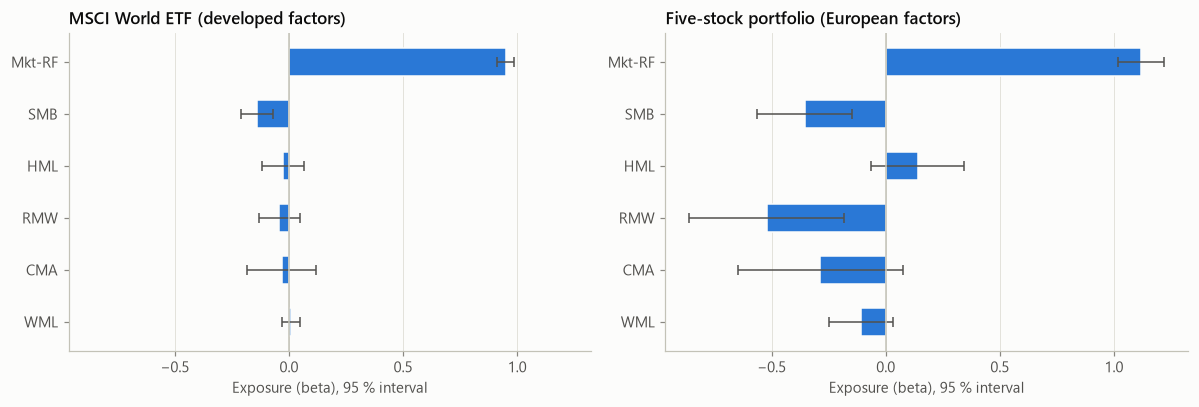

In [5]:
concentrated = portfolio_returns(returns_usd, universe.MODEL_PORTFOLIOS["concentrated"].weights)
result = fm.factor_regression(concentrated, europe)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
plot_coefficients(
    world.summary().drop("alpha"), ax=axes[0], title="MSCI World ETF (developed factors)"
)
plot_coefficients(
    result.summary().drop("alpha"), ax=axes[1], title="Five-stock portfolio (European factors)"
)
for ax in axes:
    ax.set_xlabel("Exposure (beta), 95 % interval")
fig.tight_layout()
fig.savefig(f"{FIGURES}/factor_exposures.png")
print(f"Five-stock portfolio: R^2 = {result.r_squared:.3f}")
result.summary()

## Where did the return come from?

With an intercept in the regression, the mean excess return splits exactly into alpha plus
$\beta_k \times \overline{f_k}$ for each factor.

In [6]:
pd.DataFrame(
    {
        "MSCI World ETF": fm.return_attribution(world, developed),
        "five stocks": fm.return_attribution(result, europe),
    }
).mul(12).rename_axis("annualised contribution")

,MSCI World ETF,five stocks
annualised contribution,,
alpha,2.945e-03,4.223e-02
Mkt-RF,9.741e-02,8.418e-02
SMB,1.873e-03,-1.427e-03
HML,-4.585e-05,2.041e-03
RMW,-1.032e-03,-1.332e-02
CMA,-2.593e-04,5.380e-04
WML,6.023e-04,-1.106e-02


## Are exposures stable?

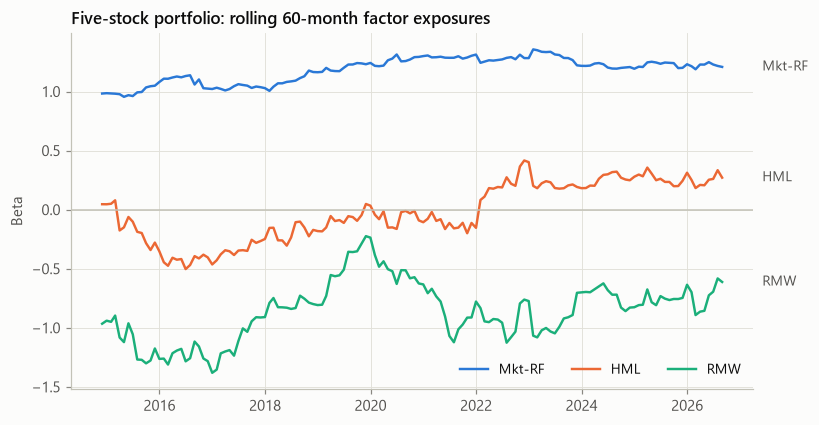

In [7]:
rolling = fm.rolling_betas(concentrated, europe, window=60)
ax = plot_lines(
    rolling[["Mkt-RF", "HML", "RMW"]],
    title="Five-stock portfolio: rolling 60-month factor exposures",
)
ax.axhline(0, color="#c3c2b7", linewidth=1.0)
ax.set_ylabel("Beta")
plt.show()

**Takeaways**

* A broad index fund is almost pure market exposure with no alpha, as expected.
* Single stocks carry large idiosyncratic risk and sizeable, time-varying style tilts.
* Factor regressions turn a vague "this stock behaves differently" into measurable exposures,
  with honest uncertainty from robust standard errors.